# Minnesota Food Shelf Statistical Analysis

This notebook tests this project's null hypothesis:

> A county's metropolitan status has no effect on its number of food shelf locations per 10,000 residents.

We find we have strong evidence for rejecting the hypothesis.

A final section analyzes variability in food shelf location hours.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
county = pd.read_pickle("data/countytable.pkl")
len(county)

87

## Food Shelf Locations Per 10k Residents: Metro and Non-Metro

In [food_shelf_eda.ipynb](https://github.com/a-location-1/mn-food-shelf-analysis/blob/main/food_shelf_eda.ipynb), we compiled a table of the 87 Minnesota counties and classified each one according to four statuses:
- `3`: Twin Cities core
- `2`: Seven-county metro area
- `1`: Metropolitan Statistical Area
- `0`: Non-Metro

Our analysis will now focus on a binary split using a `metro` column:
- `1`: Metro (`tcmetro` categories `1`, `2`, and `3`)
- `0`: Non-Metro (`tcmetro` category `0`)

In [3]:
# Adding the binary column metro:
county["metro"] = 0
county.loc[county["tcmetro"] > 0, "metro"] = 1

There are 74 Non-Metro counties and 13 Metro counties.

An important caveat is that "Non-Metro" does not equal "rural". For example, as the below tables show, St. Louis county (which has its county seat in Duluth) has a larger population than 8 of the 13 Metro counties. 

In [4]:
# Displaying the largest and smallest non-metro counties:
pd.concat(
    [
        county.loc[county["metro"] == 0, ["county", "population"]]
        .sort_values("population", ascending=False)
        .head(1),
        county.loc[county["metro"] == 0, ["county", "population"]]
        .sort_values("population")
        .head(1),
    ]
)

,county,population
71,St. Louis,200794
77,Traverse,3134


In [5]:
# Displaying the 13 Metro counties:
county.loc[county["metro"] == 1, ["county", "population"]].sort_values(
    "population"
).head(13)

,county,population
47,Mille Lacs,27577
39,Le Sueur,29458
29,Isanti,43687
12,Chisago,59105
69,Sherburne,103059
9,Carver,112628
85,Wright,154593
68,Scott,157206
81,Washington,283960
1,Anoka,376840


Our initial alternative hypothesis was that Non-Metro counties have fewer food shelf locations per 10,000 residents than Metro counties.

Investigating the proportion of food shelf locations per 10,000 residents, we have good reason to think the exact opposite is true:

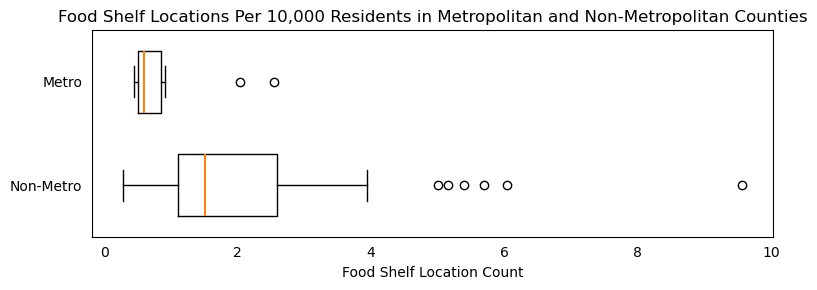

In [6]:
# Box plots for Metro and Non-Metro food shelf location counts:
metro_status = [0, 1]
labels = ["Non-Metro", "Metro"]
plotdata = [
    county.loc[county["metro"] == status, "count_per_10k"] for status in metro_status
]

fig, ax = plt.subplots(figsize=(8, 3))
ax.boxplot(
    plotdata,
    vert=False,
    patch_artist=False,
    tick_labels=labels,
    widths=0.6,
    medianprops=dict(linewidth=1.5),
)
ax.set_title(
    "Food Shelf Locations Per 10,000 Residents in Metropolitan and Non-Metropolitan Counties"
)
ax.set_xlabel("Food Shelf Location Count")
ax.tick_params(left=False, bottom=False)
plt.tight_layout()
plt.show()

Non-Metro counties have a higher proportion of food shelf locations per 10,000 residents than Metro counties. The difference is pronounced; for example, there's no overlap between the two groups' interquartile ranges.

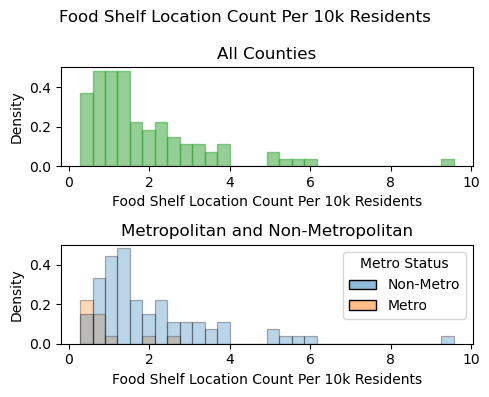

In [7]:
bin_num = 30

fig, ax = plt.subplots(2, 1, figsize=(5, 4))
ax[0].hist(
    county["count_per_10k"],
    bins=bin_num,
    density=True,
    color="tab:green",
    edgecolor="tab:green",
    linewidth=1,
    alpha=0.5,
)
ax[0].set_title("All Counties")
ax[0].set_xlabel("Food Shelf Location Count Per 10k Residents")
ax[0].set_ylabel("Density")
ax[0].set_ylim(0, 0.5)

sns.histplot(
    data=county,
    x="count_per_10k",
    hue="metro",
    element="bars",
    stat="density",
    bins=bin_num,
    common_norm=True,
    multiple="layer",
    ax=ax[1],
)

for patch in ax[1].patches:
    patch.set_alpha(0.3)
    patch.set_linewidth(0.9)

legend = ax[1].get_legend()
for text, label in zip(legend.get_texts(), ["Non-Metro", "Metro"]):
    text.set_text(label)
ax[1].get_legend().set_title("Metro Status")

ax[1].set_title("Metropolitan and Non-Metropolitan")
ax[1].set_xlabel("Food Shelf Location Count Per 10k Residents")
ax[1].set_ylabel("Density")
ax[1].set_ylim(0, 0.5)

plt.suptitle("Food Shelf Location Count Per 10k Residents")
plt.tight_layout()
plt.show()

In [8]:
round((county["count_per_10k"] <= 2).mean(), 4)

np.float64(0.6552)

Across all counties the distribution is sharply right-skewed, with most of the values (65%) falling between 0 and 2.

Nevertheless, the difference between the Metro and Non-Metro distributions is stark: the bulk of the Metro values seem to cluster below 1.0, and the Non-Metro values are densest around 1.5 and above.

In [9]:
pd.concat(
    [
        county.groupby("metro").agg({"count": ["mean", "median"]}),
        county.groupby("metro").agg({"count_per_10k": ["mean", "median"]}),
    ],
    axis=1,
).rename(index={0: "Non-Metro", 1: "Metro"}).round(4)

count        count_per_10k        
              mean median          mean  median
metro                                          
Non-Metro   4.1351    3.0        2.0731  1.5047
Metro      18.6923    7.0        0.8706  0.5987

Non-Metro counties have more than double the average number of locations: 2.07 locations per 10k versus 0.87 locations per 10k.

Is this statistically significant?

Because we have a census, yes - and we can verify it with a permutation test.

In [10]:
# Defining the test statistic and Non-Metro mean minus Metro mean:
def difference_in_means(df):
    means = df.groupby("metro")["count_per_10k"].mean()
    return np.round(means[0] - means[1], 4)


observed_value = difference_in_means(county)
print(f"Observed value: {observed_value}")

Observed value: 1.2025


In [11]:
# Permutation testing:
replicates = [observed_value]
n_sim = 20_000
sim_county = county.copy()

for _ in range(n_sim - 1):
    sim_county["metro"] = (
        sim_county["metro"].sample(frac=1, replace=False).reset_index(drop=True)
    )
    replicates.append(difference_in_means(sim_county))

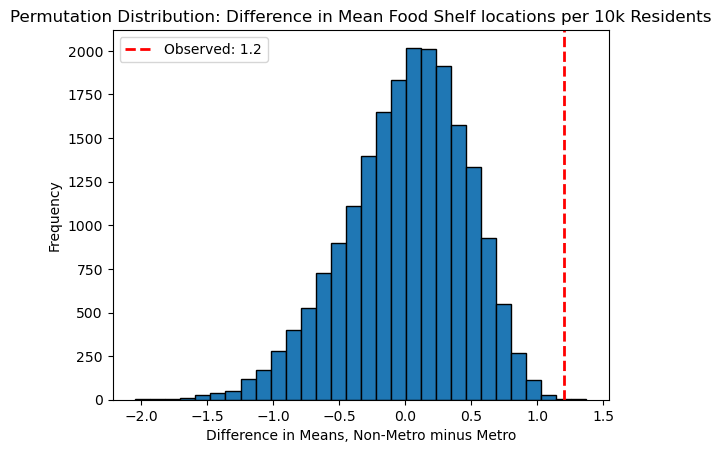

In [12]:
# Plotting the permutation distribution:
plt.hist(replicates, bins=30, edgecolor="black")
plt.axvline(
    observed_value,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Observed: {round(observed_value, 2)}",
)
plt.xlabel("Difference in Means, Non-Metro minus Metro")
plt.ylabel("Frequency")
plt.title("Permutation Distribution: Difference in Mean Food Shelf locations per 10k Residents")
plt.legend()
plt.show()

In [13]:
# Calculating the p-value:
p_value = np.mean(np.abs(replicates) >= np.abs(observed_value))
p_value

np.float64(0.0091)

In [14]:
# Investigating the skew of the permutation distribution:
pd.Series(replicates).skew()

np.float64(-0.4646166605204937)

There's a ~1% chance of observing a value as extreme as the difference between means we observe (1.2), if the null hypothesis is true. Because this is so unlikely, we reject the null hypothesis.

Our data are consistent with a hypothesis that Non-Metro counties have a greater proportion of food shelf locations per 10k residents than Metro counties.

## Food Shelf Hours Analysis

Food shelf locations differ significantly in their open hours. My expectation is that locations generally fall into two groups, those with weekly hours and those only open a few times per month. Open hours are another aspect of service availability, and could influence conclusions we might want to draw based on our analysis of locations per 10k residents. 

We don't have easy access to hours data for all 449 food shelf locations, so we'll take a 30 location sample and make an estimate about the population.

In [15]:
# Read cleaned food shelf list:
shelf = pd.read_pickle("data/shelftable.pkl")
len(shelf)

549

In [16]:
# Take a sample of food shelf locations:
n = 30
sample = shelf.sample(n, replace=False, random_state=42)
sample_per = round(len(sample) / len(shelf), 4) * 100
print(f"The sample of size {n} is {sample_per}% of the total population.")

The sample of size 30 is 5.46% of the total population.


For each of our randomly selected locations, we'll manually look up the listing on the Find Help Map to determine the number of hours the location is open per month.

We use the following rules to calculate the monthly amounts:
- 4 weeks = 1 month when converting to monthly.*
- Open is open: 
    - Hours that are "pick up only" or "appointment only" still count. 
    - A location that restricts access to certain groups still counts (E.X. Concordia University Food Shelf only serves "Concordia students, staff, faculty, and alumni").
    - A location with restrictions like ID requirements or capped visits per month still counts as open.
    - A location that offers services in addition to a food shelf still counts (E.X. Youth Link Food Shelf offers a range of "drop in" services for youth ages 16 to 24).
- "By appointment only, any time" = 0 hours.
- Day listed, but hours not listed = 1 hour.

*While it would be possible to approximate the relationship between week and month more closely using a different multiplier (E.X. 4.3), it is in our interest to shrink the gap between locations with monthly hours (which are typically quite low) and locations with weekly hours (which are typically quite high).

Examples:

| Listed Hours | Calculated Hours per month |
| ---- | ---- |
| "1st & 3rd Thursday 3-5pm" | 4 (2 hr + 2 hr) |
| "Monday – Friday: 9 am – 3:30 pm" | 130 (6.5 hr * 5 dy * 4 wk) |
| "Last Wednesday of the month 2:30 - 4:30 pm as drive through and Thursday's (except the last Thursday of the month) from 3:00 - 5:00 pm" | 8 (2 hr + 2 hr + 2 hr + 2 hr) |
| "3rd Friday of the month" | 1 |
| "Mon 3:00-5:00PM and 1st Wed of the month 4:30-6:30pm" | 10 ((2 hr * 4 wk) + 2 hr)

In [17]:
# Manually assigning monthly hours:
sample.loc[sample["name"] == "Hastings Family Service", "hours"] = 112
sample.loc[sample["name"] == "Climax Parish Food Shelf", "hours"] = 4
sample.loc[sample["name"] == "The Harbor Food Shelf at Faith Lutheran", "hours"] = 8
sample.loc[sample["name"] == "East Marshall County Emergency Food Shelf", "hours"] = 0
sample.loc[sample["name"] == "The Aliveness Project", "hours"] = 130
sample.loc[sample["name"] == "The Salvation Army Brainerd", "hours"] = 66
sample.loc[
    sample["name"] == "Community Action Center Food Shelf- Northfield", "hours"
] = 84
sample.loc[sample["name"] == "Plainview-Elgin Area Food Shelf", "hours"] = 28
sample.loc[
    sample["name"] == "Fathers Hearts and Hands Food Shelf at Solid Rock Church of God",
    "hours",
] = 1
sample.loc[sample["name"] == "Pillager Food Shelf", "hours"] = 20
sample.loc[sample["name"] == "Grand Marais / Cook County Food Shelf", "hours"] = 10
sample.loc[
    sample["name"] == "Alden Area Food Shelf-Redeemer Lutheran Church", "hours"
] = 8
sample.loc[sample["name"] == "Churches United For the Homeless", "hours"] = 10
sample.loc[
    sample["name"] == "Hope for the Community- Coon Rapids Middle School", "hours"
] = 2
sample.loc[sample["name"] == "MAS MN Blaine Food Shelf", "hours"] = 1.5
# Comet’s Cupboard (Concordia University Food Shelf)
sample.loc[sample["name"].str.contains("Cupboard"), "hours"] = 12
sample.loc[sample["name"] == "REACH-Hendrum Food Shelf", "hours"] = 28
sample.loc[sample["name"] == "ACBC Food Shelf", "hours"] = 92
sample.loc[
    sample["name"] == "Hope for the Community- Anoka Technical College", "hours"
] = 120
sample.loc[sample["name"] == "Silver Bay Area Food Shelf", "hours"] = 96
sample.loc[sample["name"] == "Roseau Area Food Shelf", "hours"] = 10
sample.loc[
    sample["name"] == "Food Shelf In-A-Box at Maple Pond Homes Pop-up Mobile", "hours"
] = 6
sample.loc[sample["name"] == "Steele County Food Shelf", "hours"] = 150
sample.loc[
    sample["name"] == "Fruit of the Vine Community Food Shelf–Duluth", "hours"
] = 16
sample.loc[sample["name"] == "Cokato Food Shelf", "hours"] = 4
sample.loc[sample["name"] == "Youth Link Food Shelf", "hours"] = 146
sample.loc[sample["name"] == "Grand Meadow Food Shelf", "hours"] = 3
sample.loc[
    sample["name"] == "Merrick Food Shelf on Arcade Street (Door 3)", "hours"
] = 24
sample.loc[sample["name"] == "Valley Food Shelf", "hours"] = 16
sample.loc[sample["name"] == "Tracy Kitchen Table Food Shelf", "hours"] = 10

In [18]:
# Adding the metro column to the sample table:
sample = sample.merge(county.loc[:, ["county", "metro"]], how="left", on="county")

In [19]:
# Displaying all food shelf locations in the sample:
sample.loc[:, ["name", "hours", "county", "metro"]].sort_values(
    "hours", ascending=False
).head(30)

,name,hours,county,metro
22,Steele County Food Shelf,150.0,Steele,0
25,Youth Link Food Shelf,146.0,Hennepin,1
4,The Aliveness Project,130.0,Hennepin,1
18,Hope for the Community- Anoka Technical College,120.0,Anoka,1
0,Hastings Family Service,112.0,Dakota,1
19,Silver Bay Area Food Shelf,96.0,Lake,0
17,ACBC Food Shelf,92.0,Anoka,1
6,Community Action Center Food Shelf- Northfield,84.0,Rice,0
5,The Salvation Army Brainerd,66.0,Crow Wing,0
16,REACH-Hendrum Food Shelf,28.0,Norman,0


We'll use these 30 food shelf locations to estimate the average monthly hours, with a bootstrapped 95% confidence interval:

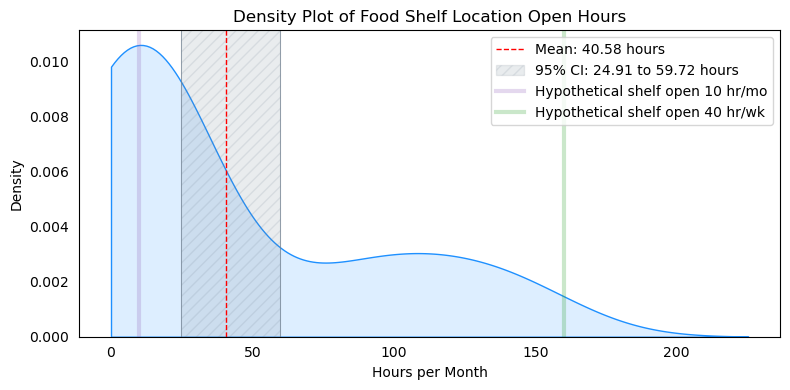

In [20]:
# Calcuating the sample mean and the confidence interval:
round_num = 2
sample_mean = round(sample["hours"].mean(), round_num)

replicates = []
for _ in range(1_000):
    replicates.append(sample.sample(frac=1, replace=True)["hours"].mean())

sample_lower_ci = round(np.quantile(replicates, 0.025), round_num)
sample_upper_ci = round(np.quantile(replicates, 0.975), round_num)

fig, ax = plt.subplots(figsize=(8, 4))

sns.kdeplot(
    sample["hours"],
    fill=True,
    clip=(0, 672),
    color="dodgerblue",
    alpha=0.15,
    ax=ax,
)
# 672 = a theoretical maximum, if a shelf was open 24/7 for 28 days

ax.axvline(
    sample_mean,
    color="r",
    linestyle="--",
    linewidth=1,
    label=f"Mean: {sample_mean} hours",
)
ax.axvline(
    sample_lower_ci,
    color="slategray",
    linestyle="-",
    linewidth=0.5,
)
ax.axvline(
    sample_upper_ci,
    color="slategray",
    linestyle="-",
    linewidth=0.5,
)
ax.axvspan(
    sample_lower_ci,
    sample_upper_ci,
    color="slategray",
    alpha=0.15,
    hatch="///",
    label=f"95% CI: {sample_lower_ci} to {sample_upper_ci} hours",
)
ax.axvline(
    10,
    color="tab:purple",
    alpha=0.25,
    linestyle="-",
    linewidth=3,
    label="Hypothetical shelf open 10 hr/mo",
)
ax.axvline(
    160,
    color="tab:green",
    alpha=0.25,
    linestyle="-",
    linewidth=3,
    label="Hypothetical shelf open 40 hr/wk",
)

ax.set_xlabel("Hours per Month")
ax.set_ylabel("Density")
ax.set_title("Density Plot of Food Shelf Location Open Hours")
ax.tick_params(left=None, bottom=None)
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
# Displaying the mode:
sample["hours"].value_counts().head(5)

hours
10.0    4
8.0     2
4.0     2
28.0    2
16.0    2
Name: count, dtype: int64

We can say with 95% confidence our population mean falls between ~24hr/mo and ~60hr/mo. In other words, we estimate an average food shelf location will be open for about 10 hours per week, plus or minus 4 hours.

However, our density distribution shows the limitation of using the mean value on right skewed data: the distribution appears roughly bimodal, with many locations open around 10 hours per month (for example, 10 is the mode of our sample locations) and another peak around 120 hours per month (about 30 weekly hours). Falling in the middle of the two lumps, the mean doesn't capture much about these trends.

These limitations are also demonstrated by the standard deviation (below) of nearly 50 hours. It is 8+ hours greater than the mean, which is consistent with a heavy skew. The high variation in the data also results in a lot of uncertainty around our standard deviation:

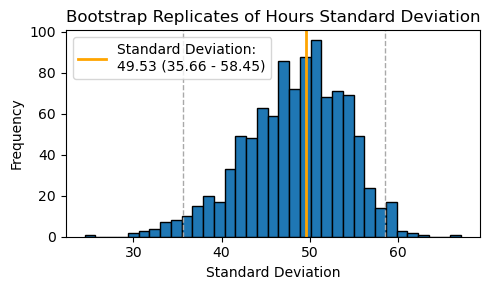

In [22]:
# Calcuating the sample std dev and the confidence interval:
round_num = 2
bin_num = 35
sample_std = round(sample["hours"].std(), round_num)

replicates = []
for _ in range(1_000):
    replicates.append(sample.sample(frac=1, replace=True)["hours"].std())

sample_lower_ci = round(np.quantile(replicates, 0.025), round_num)
sample_upper_ci = round(np.quantile(replicates, 0.975), round_num)

fig, ax = plt.subplots(figsize=(5, 3))

ax.hist(replicates, bins=bin_num, edgecolor="black")
ax.axvline(
    sample_std,
    color="orange",
    linestyle="-",
    linewidth=2,
    label=f"Standard Deviation:\n{sample_std} ({sample_lower_ci} - {sample_upper_ci})",
)
ax.axvline(sample_lower_ci, color="darkgray", linestyle="--", linewidth=1)
ax.axvline(sample_upper_ci, color="darkgray", linestyle="--", linewidth=1)

ax.set_xlabel("Standard Deviation")
ax.set_ylabel("Frequency")
ax.set_title("Bootstrap Replicates of Hours Standard Deviation")
plt.legend()
plt.tight_layout()
plt.show()

Because of the right-skewed data distribution, the boostrap distribution is also skewed.

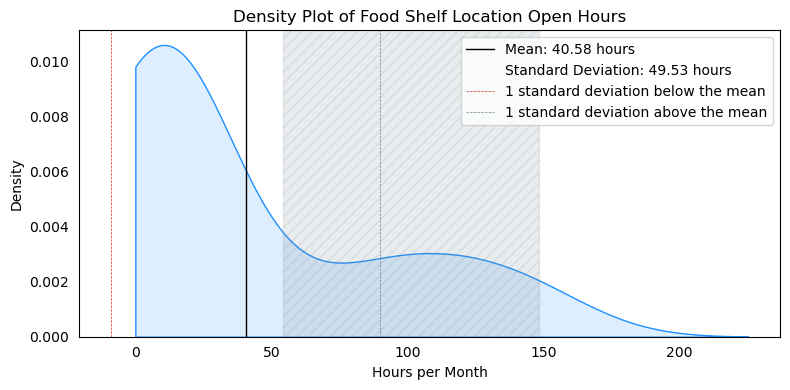

In [23]:
# Plotting the density distribution to show the CI of the standard deviation:
fig, ax = plt.subplots(figsize=(8, 4))

sns.kdeplot(
    sample["hours"],
    fill=True,
    clip=(0, 672),
    color="dodgerblue",
    alpha=0.15,
    ax=ax,
)

ax.axvline(
    sample_mean,
    color="k",
    linestyle="-",
    linewidth=1,
    label=f"Mean: {sample_mean} hours",
)

plt.plot([], [], " ", label=f"Standard Deviation: {sample_std} hours")

# 1 std dev below the mean:
ax.axvline(
    sample_mean - sample_std,
    color="tab:red",
    linestyle="--",
    linewidth=0.5,
    label="1 standard deviation below the mean",
)
# ax.axvspan(
#     sample_mean - sample_std - sample_lower_ci,
#     0,
#     color="tab:red",
#     alpha=0.15,
#     hatch="\\\\\\",
# )
# ax.axvspan(
#     0,
#     sample_mean - sample_std + sample_upper_ci,
#     color="slategray",
#     alpha=0.15,
#     hatch="\\\\\\",
#     # label=f"95% CI around 1 std dev below the mean",
# )

# 1 std dev above the mean:
ax.axvline(
    sample_mean + sample_std,
    color="slategray",
    linestyle="--",
    linewidth=0.5,
    label="1 standard deviation above the mean",
)
ax.axvspan(
    sample_mean + sample_std - sample_lower_ci,
    sample_mean + sample_std + sample_upper_ci,
    color="slategray",
    alpha=0.15,
    hatch="///",
    # label=f"95% CI around 1 std dev above the mean",
)

ax.set_xlabel("Hours per Month")
ax.set_ylabel("Density")
ax.set_title("Density Plot of Food Shelf Location Open Hours")
ax.tick_params(left=None, bottom=None)
plt.legend()
plt.tight_layout()
plt.show()

In the plot above, we show the 95% confidence interval for the arbitrary value of 1 standard deviation above the mean.

In short, our standard deviation is telling us there's a lot of variance, but we're so uncertain about it that it doesn't have much descriptive power.

Does a county's metro status help explain the hours distribution?

We'll run permutation tests on the difference in medians and the difference in means on the two groups.

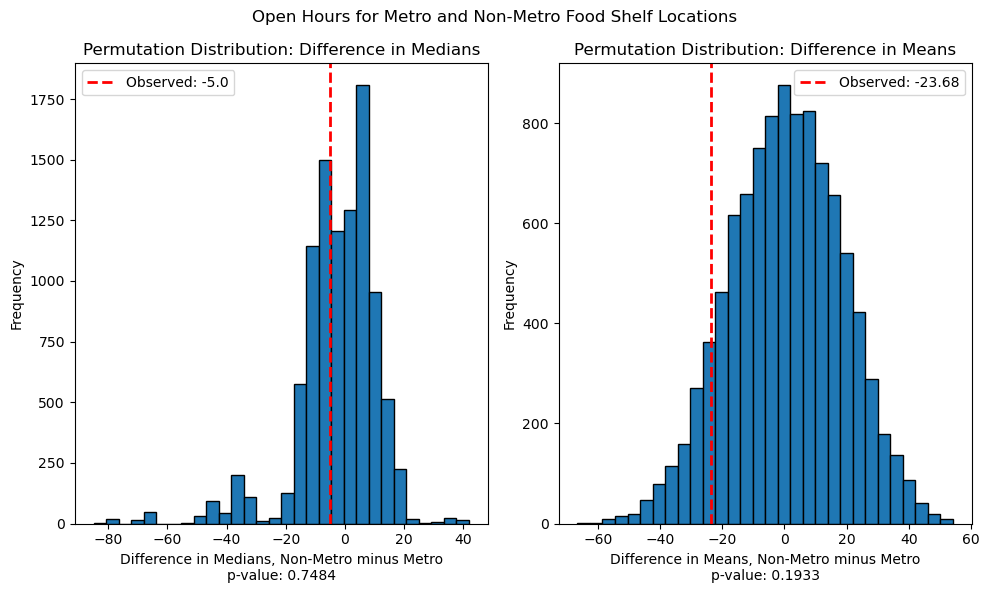

In [24]:
# Permutation testing the effect of metro status on median difference:
def difference_in_median_hours(df):
    medians = df.groupby("metro")["hours"].median()
    return np.round(medians[0] - medians[1], 4)


def difference_in_mean_hours(df):
    means = df.groupby("metro")["hours"].mean()
    return np.round(means[0] - means[1], 4)


# Median Permuting:
median_observed_value = difference_in_median_hours(sample)

median_replicates = [median_observed_value]
n_sim = 10_000
sim_sample = sample.copy()

for _ in range(n_sim - 1):
    sim_sample["metro"] = (
        sim_sample["metro"].sample(frac=1, replace=False).reset_index(drop=True)
    )
    median_replicates.append(difference_in_median_hours(sim_sample))

median_p_value = np.mean(np.abs(median_replicates) >= np.abs(median_observed_value))

# Mean Permuting:
mean_observed_value = difference_in_mean_hours(sample)

mean_replicates = [mean_observed_value]

for _ in range(n_sim - 1):
    sim_sample["metro"] = (
        sim_sample["metro"].sample(frac=1, replace=False).reset_index(drop=True)
    )
    mean_replicates.append(difference_in_mean_hours(sim_sample))

mean_p_value = np.mean(np.abs(mean_replicates) >= np.abs(mean_observed_value))

# Plotting:
fig, ax = plt.subplots(1, 2, figsize=(10, 6))

ax[0].hist(median_replicates, bins=30, edgecolor="black")
ax[0].axvline(
    median_observed_value,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Observed: {round(median_observed_value, 2)}",
)
ax[0].set_xlabel(f"Difference in Medians, Non-Metro minus Metro\np-value: {median_p_value}")
ax[0].set_ylabel("Frequency")
ax[0].set_title("Permutation Distribution: Difference in Medians")
ax[0].legend(loc='upper left')
ax[1].hist(mean_replicates, bins=30, edgecolor="black")
ax[1].axvline(
    mean_observed_value,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Observed: {round(mean_observed_value, 2)}",
)
ax[1].set_xlabel(f"Difference in Means, Non-Metro minus Metro\np-value: {mean_p_value}")
ax[1].set_ylabel("Frequency")
ax[1].set_title("Permutation Distribution: Difference in Means")
ax[1].legend(loc='upper right')

plt.suptitle("Open Hours for Metro and Non-Metro Food Shelf Locations")
plt.tight_layout()
plt.show()

In both cases, our observed value measuring a difference between the groups is explainable by random chance. Our implied null hypothesis - that there will be no difference between Metro and Non-Metro in terms of open hours - stands. 

It's not surprising that the permutation test for the difference in mean values is better behaved and more promising: while we might typically turn to medians to resist the pull of outliers, in this case our outliers seem to be a significant chunk of the data. For all its flaws, the mean better reveals the limitations of the summary statistics applied thus far.

---